# Gemini Validation and Conservative Routing

## tl;dr

A 300-ticket Gemini Free Tier sample achieved 63.3% category accuracy, compared with 38.0% for priority and 27.7% for department. The resulting operating policy permits category-only auto-routing for `Request` at a 60% empirical-accuracy threshold; priority and department remain human-reviewed.

## Context & Methods

This notebook reads the locally generated validation and Power BI output tables. It makes no API calls. The sample is representative but limited to 300 successful English-language classifications from a synthetic customer-support dataset. Routing decisions use measured category accuracy against known labels, not the model's self-reported confidence.

### Key Assumptions

- The 60% threshold is a conservative operating rule for this portfolio demonstration.
- A category must have at least 30 evaluated tickets to be eligible.
- Estimated savings are scenario outputs, not observed production savings.

## Data

The notebook uses `data/processed/classification_metrics.json` and prepared CSV tables from `outputs/tables/`.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
metrics_path = project_root / 'data' / 'processed' / 'classification_metrics.json'
tables_path = project_root / 'outputs' / 'tables'

with metrics_path.open(encoding='utf-8') as file:
    metrics = json.load(file)

routing = pd.read_csv(tables_path / 'category_routing_recommendations.csv')
scenarios = pd.read_csv(tables_path / 'routing_threshold_scenarios.csv')
root_causes = pd.read_csv(tables_path / 'root_cause_normalised_distribution.csv')

## Results

### 1. Validation Metrics

In [2]:
accuracy_summary = pd.DataFrame(
    {'label': name.title(), 'accuracy': result['accuracy']}
    for name, result in metrics.items()
)
accuracy_summary['accuracy_pct'] = (accuracy_summary['accuracy'] * 100).round(1)
accuracy_summary

,label,accuracy,accuracy_pct
0,Category,0.633333,63.3
1,Priority,0.380000,38.0
2,Department,0.276667,27.7


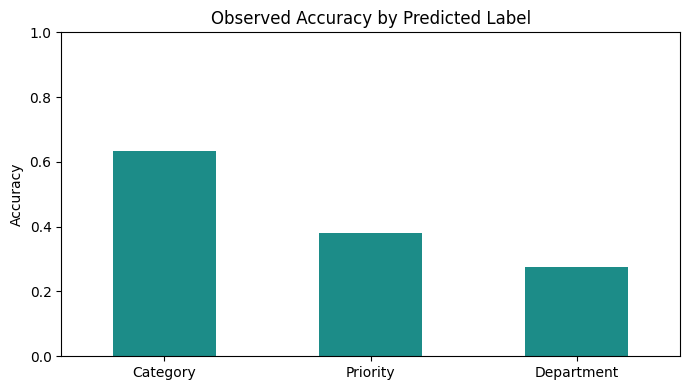

In [3]:
ax = accuracy_summary.plot.bar(x='label', y='accuracy', legend=False, color='#1C8C88', figsize=(7, 4))
ax.set_title('Observed Accuracy by Predicted Label')
ax.set_xlabel('')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 2. Empirical Category Routing Decision

In [4]:
routing[['category', 'ticket_count', 'empirical_accuracy', 'routing_recommendation', 'routing_scope']]

,category,ticket_count,empirical_accuracy,routing_recommendation,routing_scope
0,Request,89,1.000000,Auto-route category,Category only; priority and department remain ...
1,Incident,121,0.570248,Human review,Category only; priority and department remain ...
2,Problem,60,0.533333,Human review,Category only; priority and department remain ...
3,Change,30,0.000000,Human review,Category only; priority and department remain ...


In [5]:
scenarios[['accuracy_threshold', 'automation_rate', 'estimated_auto_route_errors', 'minutes_saved_sample']].head(4)

,accuracy_threshold,automation_rate,estimated_auto_route_errors,minutes_saved_sample
0,0.50,0.900000,80,1080.0
1,0.55,0.700000,52,840.0
2,0.60,0.296667,0,356.0
3,0.65,0.296667,0,356.0


### 3. Normalised Recurring Issues

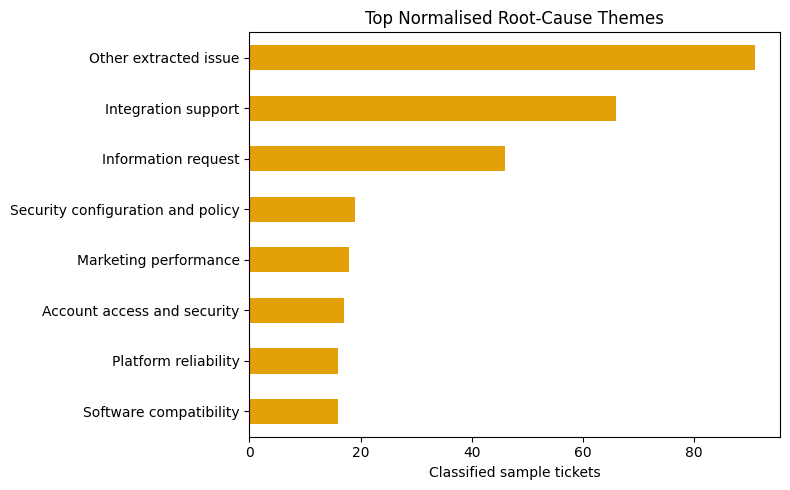

In [6]:
top_root_causes = root_causes.head(8).sort_values('ticket_count')
ax = top_root_causes.plot.barh(x='root_cause_theme', y='ticket_count', legend=False, color='#E3A008', figsize=(8, 5))
ax.set_title('Top Normalised Root-Cause Themes')
ax.set_xlabel('Classified sample tickets')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Takeaways

- Category is the only validated label suitable for a restricted routing experiment in this sample.
- At the 60% empirical-accuracy threshold, `Request` is the sole category eligible for category-only auto-routing.
- Priority and department predictions remain human-reviewed because their observed accuracy is too low for reliable automation.
- Root-cause themes are preliminary and should be checked against individual ticket text before operational changes are prioritised. Observed sample shares are evidence of demand concentration, not ticket-deflection forecasts.